# Hierarchical Intrusion Detection from Multi-Class PMU Data

This notebook implements the final hierarchical intrusion detection system using
the released multi-class PMU dataset (37 available scenarios).
All models are trained from the same dataset using task-specific labels derived
from the `marker` attribute.

In [1]:
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)

# Display settings (optional)
pd.set_option("display.max_columns", 200)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import joblib

In [2]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    class_names,
    title="Confusion Matrix",
    figsize=(7, 5)
):
    """
    Plot a confusion matrix heatmap with counts.

    Parameters:
    - y_true: true labels
    - y_pred: predicted labels
    - class_names: list of class names (order must match labels)
    - title: plot title
    - figsize: figure size
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [3]:
DATA_PATH = "../data/merged/multi_class_dataset_clean_FULL.csv"

df = pd.read_csv(DATA_PATH)

df.shape

(78377, 133)

In [4]:
df["marker"].nunique(), sorted(df["marker"].unique())[:5], sorted(df["marker"].unique())[-5:]

(37,
 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)],
 [np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41)])

In [5]:
FEATURE_COLS = [
    c for c in df.columns
    if c not in ["marker", "label", "label_name"]
]

len(FEATURE_COLS)
X_ALL = df[FEATURE_COLS]

In [6]:
"marker" in FEATURE_COLS

False

In [7]:
# ================================
# Section 3 — Hierarchical Label Grouping
# ================================

# ---------- Scenario Groups ----------

# Non-Attack scenarios
SLG_IDS     = [1, 2, 3, 4, 5, 6]
MAINT_IDS   = [13, 14]
NORMAL_IDS  = [41]

NON_ATTACK_IDS = SLG_IDS + MAINT_IDS + NORMAL_IDS

# Attack families
DI_IDS  = [7, 8, 9, 10, 11, 12]              # Data Injection
RT_IDS  = [15, 16, 17, 18, 19, 20]           # Remote Tripping
RSC_IDS = [21, 22, 23, 24, 25, 26, 27, 28, 
           29, 30, 35, 36, 37, 38, 39, 40]   # Relay Setting Change


# ---------- M1: Attack vs Non-Attack ----------
# 0 = Attack 
# 1 = Non-Attack
def map_M1(marker):
    return 1 if marker in NON_ATTACK_IDS else 0


# ---------- M2: Non-Attack Subtype ----------
# 0 = SLG Faults
# 1 = Line Maintenance
# 2 = Normal Operation
def map_M2(marker):
    if marker in SLG_IDS:
        return 0  # SLG Faults
    elif marker in MAINT_IDS:
        return 1  # Line Maintenance
    elif marker in NORMAL_IDS:
        return 2  # Normal Operation
    else:
        return None


# ---------- M3: Attack Family ----------
# 0 = Data Injection
# 1 = Remote Tripping
# 2 = Relay Setting Change
def map_M3(marker):
    if marker in DI_IDS:
        return 0
    elif marker in RT_IDS:
        return 1
    elif marker in RSC_IDS:
        return 2
    else:
        return None


# ---------- M4: Data Injection Subtypes ----------
DI_MAP = {k: i for i, k in enumerate(DI_IDS)}

def map_M4(marker):
    return DI_MAP.get(marker, None)


# ---------- M5: Remote Tripping Subtypes ----------
RT_MAP = {k: i for i, k in enumerate(RT_IDS)}

def map_M5(marker):
    return RT_MAP.get(marker, None)


# ---------- M6: Relay Setting Change Subtypes ----------
RSC_MAP = {k: i for i, k in enumerate(RSC_IDS)}

def map_M6(marker):
    return RSC_MAP.get(marker, None)


In [8]:
X_M1 = df[FEATURE_COLS]
y_M1 = df["marker"].apply(map_M1)
y_M1.value_counts()

marker
0    55663
1    22714
Name: count, dtype: int64

In [9]:
X_train_M1, X_test_M1, y_train_M1, y_test_M1 = train_test_split(
    X_M1,
    y_M1,
    test_size=0.2,
    stratify=y_M1,
    random_state=42
)

In [10]:
M1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

              precision    recall  f1-score   support

      Attack       0.85      0.46      0.60     11133
  Non-Attack       0.38      0.81      0.51      4543

    accuracy                           0.56     15676
   macro avg       0.62      0.63      0.56     15676
weighted avg       0.72      0.56      0.57     15676



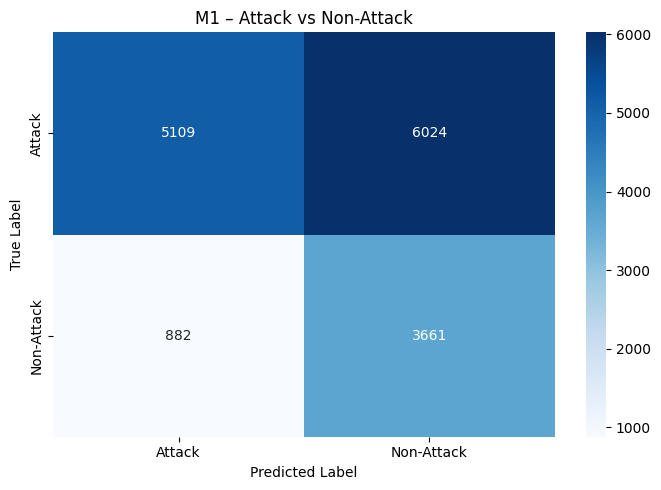

In [11]:
M1.fit(X_train_M1, y_train_M1)

y_pred_M1 = M1.predict(X_test_M1)

print(classification_report(
    y_test_M1,
    y_pred_M1,
    target_names=["Attack", "Non-Attack"]
))

plot_confusion_matrix(
    y_true=y_test_M1,
    y_pred=y_pred_M1,
    class_names=["Attack", "Non-Attack"],
    title="M1 – Attack vs Non-Attack"
)

In [12]:
df_M2 = df[df["marker"].isin(NON_ATTACK_IDS)].copy()
print("df_M2 shape:", df_M2.shape)

df_M2 shape: (22714, 133)


In [13]:
X_M2 = df_M2[FEATURE_COLS]
y_M2 = df_M2["marker"].apply(map_M2)

print("M2 class counts:")
print(y_M2.value_counts())

M2 class counts:
marker
0    15000
2     4405
1     3309
Name: count, dtype: int64


In [14]:
X_train_M2, X_test_M2, y_train_M2, y_test_M2 = train_test_split(
    X_M2,
    y_M2,
    test_size=0.2,
    stratify=y_M2,
    random_state=42
)

print("Train distribution:\n", y_train_M2.value_counts(normalize=True))
print("\nTest distribution:\n", y_test_M2.value_counts(normalize=True))

Train distribution:
 marker
0    0.660393
2    0.193935
1    0.145672
Name: proportion, dtype: float64

Test distribution:
 marker
0    0.660357
2    0.193925
1    0.145719
Name: proportion, dtype: float64


In [21]:
M2 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
M2.fit(X_train_M2, y_train_M2)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

                  precision    recall  f1-score   support

      SLG Faults       0.94      0.99      0.96      3000
Line Maintenance       0.96      0.74      0.84       662
Normal Operation       0.99      0.97      0.98       881

        accuracy                           0.95      4543
       macro avg       0.96      0.90      0.93      4543
    weighted avg       0.95      0.95      0.95      4543



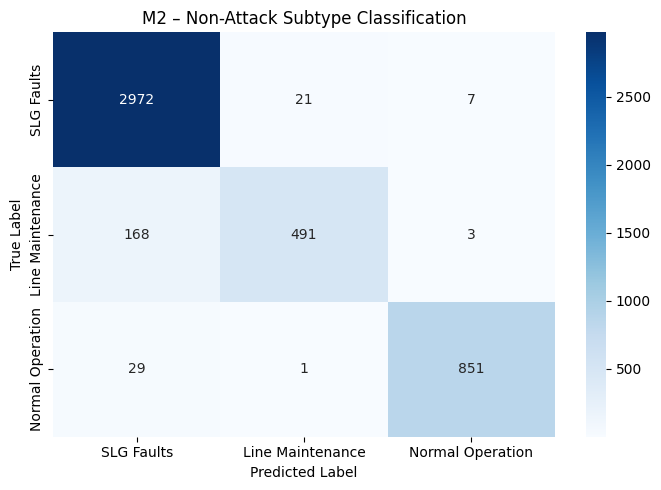

In [22]:
y_pred_M2 = M2.predict(X_test_M2)

print(classification_report(
    y_test_M2,
    y_pred_M2,
    target_names=["SLG Faults", "Line Maintenance", "Normal Operation"]
))

plot_confusion_matrix(
    y_true=y_test_M2,
    y_pred=y_pred_M2,
    class_names=["SLG Faults", "Line Maintenance", "Normal Operation"],
    title="M2 – Non-Attack Subtype Classification"
)

In [23]:
assert "marker" not in FEATURE_COLS

In [24]:
# ================================
# M3 Dataset Construction
# ================================

# Keep only attack samples
df_M3 = df[~df["marker"].isin(NON_ATTACK_IDS)].copy()

print("df_M3 shape:", df_M3.shape)

# Features and labels
X_M3 = df_M3[FEATURE_COLS]
y_M3 = df_M3["marker"].apply(map_M3)

print("\nM3 class counts:")
print(y_M3.value_counts())

df_M3 shape: (55663, 133)

M3 class counts:
marker
2    37344
0     9582
1     8737
Name: count, dtype: int64


In [25]:
X_train_M3, X_test_M3, y_train_M3, y_test_M3 = train_test_split(
    X_M3,
    y_M3,
    test_size=0.2,
    stratify=y_M3,
    random_state=42
)

print("Train distribution:\n", y_train_M3.value_counts(normalize=True))
print("\nTest distribution:\n", y_test_M3.value_counts(normalize=True))

Train distribution:
 marker
2    0.670896
0    0.172131
1    0.156973
Name: proportion, dtype: float64

Test distribution:
 marker
2    0.670888
0    0.172191
1    0.156921
Name: proportion, dtype: float64


In [26]:
M3 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

M3.fit(X_train_M3, y_train_M3)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

M3 Classification Report:
                      precision    recall  f1-score   support

      Data Injection       0.92      0.79      0.85      1917
     Remote Tripping       0.91      0.79      0.84      1747
Relay Setting Change       0.92      0.98      0.95      7469

            accuracy                           0.92     11133
           macro avg       0.92      0.85      0.88     11133
        weighted avg       0.92      0.92      0.91     11133



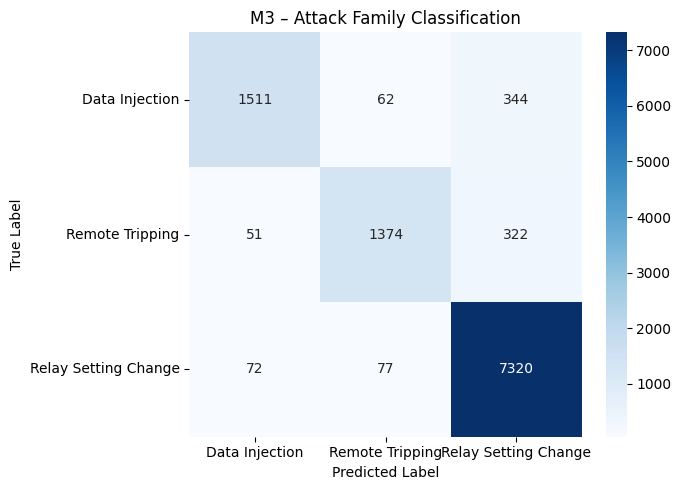

In [28]:
# ================================
# M3 Evaluation
# ================================

y_pred_M3 = M3.predict(X_test_M3)

print("M3 Classification Report:")
print(classification_report(
    y_test_M3,
    y_pred_M3,
    target_names=[
        "Data Injection",
        "Remote Tripping",
        "Relay Setting Change"
    ]
))

plot_confusion_matrix(
    y_true=y_test_M3,
    y_pred=y_pred_M3,
    class_names=[
        "Data Injection",
        "Remote Tripping",
        "Relay Setting Change"
    ],
    title="M3 – Attack Family Classification"
)

In [29]:
# ================================
# M4 Dataset Construction
# ================================

df_M4 = df[df["marker"].isin(DI_IDS)].copy()

print("df_M4 shape:", df_M4.shape)

X_M4 = df_M4[FEATURE_COLS]
y_M4 = df_M4["marker"].apply(map_M4)

print("\nM4 class counts:")
print(y_M4.value_counts())

df_M4 shape: (9582, 133)

M4 class counts:
marker
5    1963
4    1917
3    1753
0    1423
2    1269
1    1257
Name: count, dtype: int64


In [30]:
X_train_M4, X_test_M4, y_train_M4, y_test_M4 = train_test_split(
    X_M4,
    y_M4,
    test_size=0.2,
    stratify=y_M4,
    random_state=42
)

print("Train distribution:\n", y_train_M4.value_counts(normalize=True))
print("\nTest distribution:\n", y_test_M4.value_counts(normalize=True))

Train distribution:
 marker
5    0.204827
4    0.200130
3    0.182909
0    0.148467
2    0.132420
1    0.131246
Name: proportion, dtype: float64

Test distribution:
 marker
5    0.205008
4    0.199791
3    0.183099
0    0.148670
2    0.132499
1    0.130934
Name: proportion, dtype: float64


In [31]:
M4 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

M4.fit(X_train_M4, y_train_M4)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

              precision    recall  f1-score   support

DI L1 10–19%       0.78      0.84      0.81       285
DI L1 20–79%       0.83      0.84      0.84       251
DI L1 80–90%       0.86      0.79      0.82       254
DI L2 10–19%       0.92      0.89      0.91       351
DI L2 20–79%       0.92      0.89      0.91       383
DI L2 80–90%       0.89      0.93      0.91       393

    accuracy                           0.87      1917
   macro avg       0.87      0.86      0.87      1917
weighted avg       0.87      0.87      0.87      1917



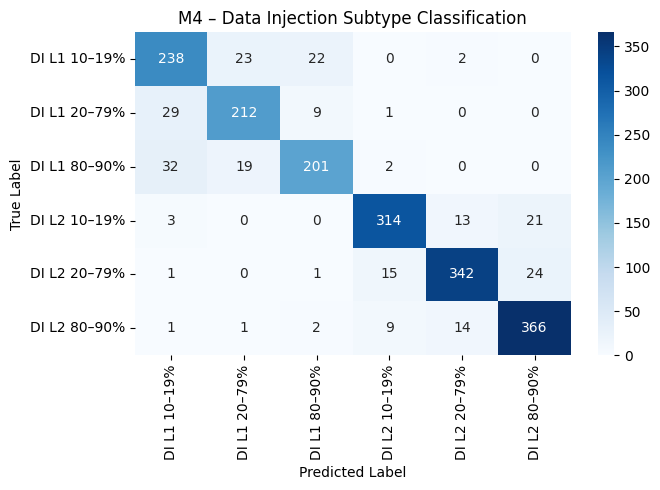

In [32]:
y_pred_M4 = M4.predict(X_test_M4)

print(classification_report(
    y_test_M4,
    y_pred_M4,
    target_names=[
        "DI L1 10–19%",
        "DI L1 20–79%",
        "DI L1 80–90%",
        "DI L2 10–19%",
        "DI L2 20–79%",
        "DI L2 80–90%"
    ]
))

plot_confusion_matrix(
    y_true=y_test_M4,
    y_pred=y_pred_M4,
    class_names=[
        "DI L1 10–19%",
        "DI L1 20–79%",
        "DI L1 80–90%",
        "DI L2 10–19%",
        "DI L2 20–79%",
        "DI L2 80–90%"
    ],
    title="M4 – Data Injection Subtype Classification"
)

In [33]:
# ================================
# M5 Dataset Construction
# ================================

df_M5 = df[df["marker"].isin(RT_IDS)].copy()

print("df_M5 shape:", df_M5.shape)

X_M5 = df_M5[FEATURE_COLS]
y_M5 = df_M5["marker"].apply(map_M5)

print("\nM5 class counts:")
print(y_M5.value_counts())

df_M5 shape: (8737, 133)

M5 class counts:
marker
4    1945
5    1517
0    1363
1    1354
2    1308
3    1250
Name: count, dtype: int64


In [34]:
X_train_M5, X_test_M5, y_train_M5, y_test_M5 = train_test_split(
    X_M5,
    y_M5,
    test_size=0.2,
    stratify=y_M5,
    random_state=42
)

In [35]:
M5 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

M5.fit(X_train_M5, y_train_M5)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

              precision    recall  f1-score   support

       RT R1       0.89      0.91      0.90       273
       RT R2       0.94      0.90      0.92       271
       RT R3       0.93      0.94      0.93       262
       RT R4       0.94      0.92      0.93       250
  RT R1 & R2       0.90      0.93      0.92       389
  RT R3 & R4       0.93      0.93      0.93       303

    accuracy                           0.92      1748
   macro avg       0.92      0.92      0.92      1748
weighted avg       0.92      0.92      0.92      1748



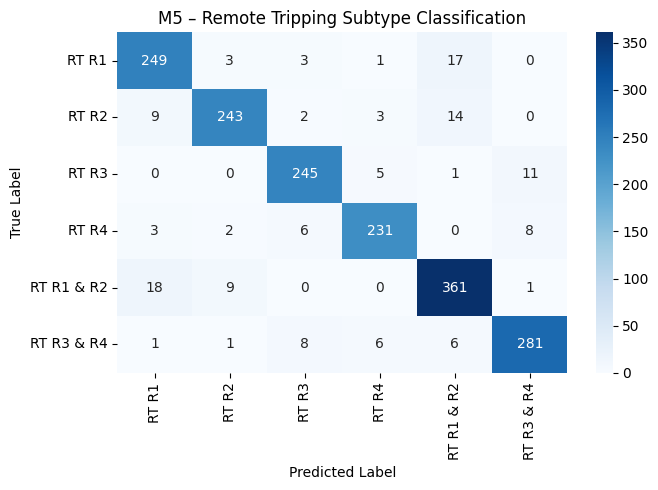

In [37]:
y_pred_M5 = M5.predict(X_test_M5)

print(classification_report(
    y_test_M5,
    y_pred_M5,
    target_names=[
        "RT R1",
        "RT R2",
        "RT R3",
        "RT R4",
        "RT R1 & R2",
        "RT R3 & R4"
    ]
))

plot_confusion_matrix(
    y_true=y_test_M5,
    y_pred=y_pred_M5,
    class_names=[
        "RT R1",
        "RT R2",
        "RT R3",
        "RT R4",
        "RT R1 & R2",
        "RT R3 & R4"
    ],
    title="M5 – Remote Tripping Subtype Classification"
)

In [38]:
# -------------------------------
# M6 Dataset Construction
# -------------------------------

df_M6 = df[df["marker"].isin(RSC_IDS)].copy()

print("df_M6 shape:", df_M6.shape)

X_M6 = df_M6[FEATURE_COLS]
y_M6 = df_M6["marker"].apply(map_M6)

print("\nM6 class counts:")
print(y_M6.value_counts().sort_index())

df_M6 shape: (37344, 133)

M6 class counts:
marker
0     1242
1     1320
2     2635
3     2040
4     2481
5     2099
6     1630
7     2061
8     2128
9     2368
10    4487
11    4685
12    2716
13    2306
14    1474
15    1672
Name: count, dtype: int64


In [39]:
X_train_M6, X_test_M6, y_train_M6, y_test_M6 = train_test_split(
    X_M6,
    y_M6,
    test_size=0.2,
    stratify=y_M6,
    random_state=42
)

print("Train distribution:\n", y_train_M6.value_counts(normalize=True).sort_index())
print("\nTest distribution:\n", y_test_M6.value_counts(normalize=True).sort_index())

Train distribution:
 marker
0     0.033272
1     0.035347
2     0.070561
3     0.054628
4     0.066444
5     0.056201
6     0.043649
7     0.055197
8     0.056971
9     0.063397
10    0.120134
11    0.125456
12    0.072736
13    0.061757
14    0.039464
15    0.044787
Name: proportion, dtype: float64

Test distribution:
 marker
0     0.033204
1     0.035346
2     0.070558
3     0.054626
4     0.066408
5     0.056232
6     0.043647
7     0.055161
8     0.057036
9     0.063462
10    0.120230
11    0.125452
12    0.072700
13    0.061722
14    0.039497
15    0.044718
Name: proportion, dtype: float64


In [40]:
M6 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

M6.fit(X_train_M6, y_train_M6)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

M6 Classification Report:
                         precision    recall  f1-score   support

      RSC R1 (L1 Fault)       0.83      0.72      0.77       248
    RSC R1 (High Fault)       0.85      0.77      0.81       264
     RSC R2 (Low Fault)       0.93      0.91      0.92       527
     RSC R2 (Mid Fault)       0.91      0.88      0.90       408
    RSC R2 (High Fault)       0.88      0.91      0.89       496
     RSC R3 (Low Fault)       0.85      0.87      0.86       420
     RSC R3 (Mid Fault)       0.92      0.87      0.89       326
    RSC R3 (High Fault)       0.97      0.87      0.91       412
     RSC R4 (Low Fault)       0.91      0.85      0.88       426
    RSC R4 (High Fault)       0.90      0.86      0.88       474
            RSC R1 & R2       0.92      0.96      0.94       898
     RSC R1 & R2 (High)       0.87      0.93      0.90       937
            RSC R3 & R4       0.79      0.89      0.84       543
     RSC R3 & R4 (High)       0.88      0.92      0.90       46

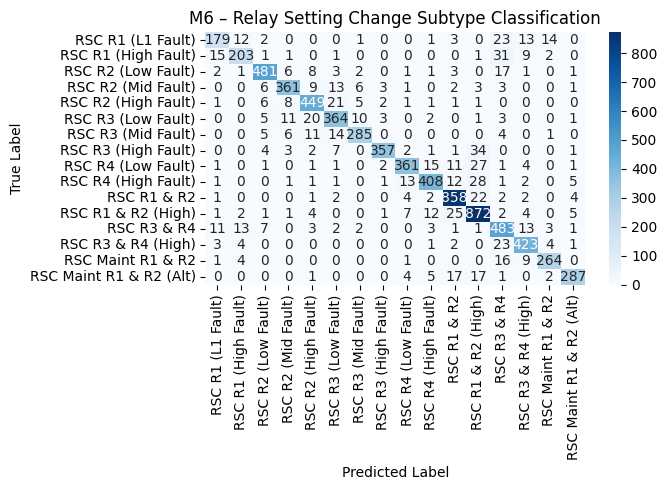

In [42]:
y_pred_M6 = M6.predict(X_test_M6)

print("M6 Classification Report:")
print(classification_report(
    y_test_M6,
    y_pred_M6,
    target_names=[
        "RSC R1 (L1 Fault)",
        "RSC R1 (High Fault)",
        "RSC R2 (Low Fault)",
        "RSC R2 (Mid Fault)",
        "RSC R2 (High Fault)",
        "RSC R3 (Low Fault)",
        "RSC R3 (Mid Fault)",
        "RSC R3 (High Fault)",
        "RSC R4 (Low Fault)",
        "RSC R4 (High Fault)",
        "RSC R1 & R2",
        "RSC R1 & R2 (High)",
        "RSC R3 & R4",
        "RSC R3 & R4 (High)",
        "RSC Maint R1 & R2",
        "RSC Maint R1 & R2 (Alt)"
    ]
))

plot_confusion_matrix(
    y_true=y_test_M6,
    y_pred=y_pred_M6,
    class_names=[
        "RSC R1 (L1 Fault)",
        "RSC R1 (High Fault)",
        "RSC R2 (Low Fault)",
        "RSC R2 (Mid Fault)",
        "RSC R2 (High Fault)",
        "RSC R3 (Low Fault)",
        "RSC R3 (Mid Fault)",
        "RSC R3 (High Fault)",
        "RSC R4 (Low Fault)",
        "RSC R4 (High Fault)",
        "RSC R1 & R2",
        "RSC R1 & R2 (High)",
        "RSC R3 & R4",
        "RSC R3 & R4 (High)",
        "RSC Maint R1 & R2",
        "RSC Maint R1 & R2 (Alt)"
    ],
    title="M6 – Relay Setting Change Subtype Classification"
)